# Sentiment Classification: CNN vs DistilBERT vs Hybrid
## Complete Deep Learning Comparison Study

This notebook implements and evaluates three sentiment classification models:
1. **Multi-kernel CNN** (TensorFlow/Keras)
2. **DistilBERT** (PyTorch, trained from scratch)
3. **Hybrid CNN + DistilBERT** (PyTorch)

All models are trained from scratch on Amazon Reviews data with comprehensive evaluation and IEEE-style metrics reporting.

## Section 0: Setup and Dependencies

In [1]:
import subprocess
import sys

# Install required packages
packages = [
    'tensorflow',
    'torch',
    'transformers',
    'scikit-learn',
    'pandas',
    'numpy',
    'matplotlib',
    'seaborn',
    'tabulate',
    'nltk'
]

for package in packages:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", package])

print("✓ All dependencies installed")

✓ All dependencies installed


In [2]:
# Standard imports
import os
import re
import time
import pickle
import random
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tabulate import tabulate

# Deep Learning
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.utils import to_categorical

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from transformers import DistilBertModel, DistilBertConfig, DistilBertTokenizerFast

# Sklearn for metrics
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    matthews_corrcoef, cohen_kappa_score, roc_auc_score, auc,
    confusion_matrix, classification_report, roc_curve, precision_recall_curve,
    log_loss
)
from sklearn.utils.class_weight import compute_class_weight

# NLTK stopwords
import nltk
nltk.download('stopwords', quiet=True)
from nltk.corpus import stopwords

print("✓ All imports completed successfully")

✓ All imports completed successfully


## Section 1: Set Random Seeds for Reproducibility

In [3]:
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

os.environ['PYTHONHASHSEED'] = str(SEED)
os.environ['TF_DETERMINISTIC_OPS'] = '1'

print("✓ Random seeds set to 42 for reproducibility")

✓ Random seeds set to 42 for reproducibility


## Section 2: Data Loading and Preprocessing

In [10]:
def load_and_preprocess_data(csv_path):
    """Load Amazon Reviews CSV, map ratings to sentiment classes, combine review title and text, and clean the text."""

    print("\n" + "="*70)
    print("SECTION 2: DATA LOADING AND PREPROCESSING")
    print("="*70)

    # Load CSV
    # Added engine='python' and on_bad_lines='skip' for more robust parsing of potentially malformed CSVs
    df = pd.read_csv(csv_path, engine='python', on_bad_lines='skip')
    print(f"Loaded CSV with {len(df)} reviews")

    # Extract rating number from "Rated X out of 5 stars" format
    def extract_rating(rating_str):
        match = re.search(r'Rated (\d) out of 5 stars', str(rating_str))
        return int(match.group(1)) if match else None

    df['rating_numeric'] = df['Rating'].apply(extract_rating)

    # Map to sentiment classes: 1-2 → 0 (Negative), 3 → 1 (Neutral), 4-5 → 2 (Positive)
    def rating_to_sentiment(rating):
        if rating in [1, 2]:
            return 0  # Negative
        elif rating == 3:
            return 1  # Neutral
        elif rating in [4, 5]:
            return 2  # Positive
        return None

    df['sentiment'] = df['rating_numeric'].apply(rating_to_sentiment)
    df = df[df['sentiment'].notna()].reset_index(drop=True)

    print(f"After filtering: {len(df)} reviews")
    print(f"Sentiment distribution:")
    print(f"  Negative (1-2 stars): {(df['sentiment'] == 0).sum()}")
    print(f"  Neutral  (3 stars):   {(df['sentiment'] == 1).sum()}")
    print(f"  Positive (4-5 stars): {(df['sentiment'] == 2).sum()}")

    # Combine Review Title and Review Text
    df['combined_text'] = (df['Review Title'].fillna('') + ' ' +
                           df['Review Text'].fillna('')).str.strip()

    # Text cleaning function
    stop_words = set(stopwords.words('english'))

    def clean_text(text):
        """Clean text: lowercase, remove HTML/URLs/digits/punctuation, remove stopwords"""
        text = str(text).lower()
        text = re.sub(r'<[^>]+>', '', text)
        text = re.sub(r'http\S+|www\S+|https\S+', '', text)
        text = re.sub(r'\d+', '', text)
        text = re.sub(r'[^\w\s]', ' ', text)
        text = re.sub(r'\s+', ' ', text).strip()

        words = text.split()
        words = [w for w in words if w not in stop_words]
        text = ' '.join(words)
        return text

    print(f"\nCleaning text...")
    df['cleaned_text'] = df['combined_text'].apply(clean_text)

    # Remove empty texts
    df = df[df['cleaned_text'].str.len() > 0].reset_index(drop=True)
    print(f"After removing empty texts: {len(df)} reviews")

    texts = df['cleaned_text'].tolist()
    labels = df['sentiment'].astype(int).tolist() # Convert to int explicitly

    # Show sample
    sample_idx = np.random.randint(0, len(texts))
    print(f"\nSample review (index {sample_idx}):")
    print(f"  Original: {df['combined_text'].iloc[sample_idx][:150]}...")
    print(f"  Cleaned:  {texts[sample_idx][:150]}...")
    print(f"  Sentiment: {['Negative', 'Neutral', 'Positive'][labels[sample_idx]]}")

    return texts, labels

# NOTE: Upload Amazon_Reviews.csv to Colab's file system, then adjust path below
# For Colab: use '/content/Amazon_Reviews.csv' after uploading via Files panel
csv_path = '/content/Amazon_Reviews.csv'  # Adjust path as needed

texts, labels = load_and_preprocess_data(csv_path)
labels = np.array(labels)
print(f"\n✓ Loaded {len(texts)} reviews with {len(np.unique(labels))} sentiment classes")


SECTION 2: DATA LOADING AND PREPROCESSING
Loaded CSV with 21214 reviews
After filtering: 21055 reviews
Sentiment distribution:
  Negative (1-2 stars): 14350
  Neutral  (3 stars):   885
  Positive (4-5 stars): 5820

Cleaning text...
After removing empty texts: 21055 reviews

Sample review (index 5390):
  Original: This is why people pirate shows I paid for a subscription service that eventually got bought out by amazon (LoveFilm).Now 75% of the films / series on...
  Cleaned:  people pirate shows paid subscription service eventually got bought amazon lovefilm films series site ppv different subscription service even specific...
  Sentiment: Negative

✓ Loaded 21055 reviews with 3 sentiment classes


### Create Stratified Train-Test Split

In [11]:
def create_splits(texts, labels, test_size=0.2, random_state=SEED):
    """Create stratified train-test split (same indices for all models)."""
    indices = np.arange(len(texts))

    train_indices, test_indices, train_texts, test_texts, train_labels, test_labels = \
        train_test_split(
            indices, texts, labels,
            test_size=test_size,
            stratify=labels,
            random_state=random_state
        )

    return train_texts, test_texts, train_labels, test_labels, train_indices, test_indices

train_texts, test_texts, train_labels, test_labels, train_idx, test_idx = \
    create_splits(texts, labels)

print(f"\n✓ Train set: {len(train_texts)} samples")
print(f"✓ Test set: {len(test_texts)} samples")
print(f"  Train sentiment distribution: {np.bincount(train_labels)}")
print(f"  Test sentiment distribution: {np.bincount(test_labels)}")

# Compute class weights for all models
class_weights = compute_class_weight(
    'balanced',
    classes=np.unique(train_labels),
    y=train_labels
)
class_weight_dict = {i: w for i, w in enumerate(class_weights)}
print(f"\n✓ Class weights (for balanced training):")
for cls, weight in class_weight_dict.items():
    print(f"  Class {cls}: {weight:.4f}")


✓ Train set: 16844 samples
✓ Test set: 4211 samples
  Train sentiment distribution: [11480   708  4656]
  Test sentiment distribution: [2870  177 1164]

✓ Class weights (for balanced training):
  Class 0: 0.4891
  Class 1: 7.9303
  Class 2: 1.2059


## Section 3: Model 1 - Multi-Kernel CNN (TensorFlow/Keras)

In [12]:
print("\n" + "="*70)
print("SECTION 3: MODEL 1 - MULTI-KERNEL CNN (TensorFlow/Keras)")
print("="*70)

# Tokenization
VOCAB_SIZE = 20000
MAX_LENGTH = 200

tokenizer_cnn = Tokenizer(num_words=VOCAB_SIZE, oov_token='<OOV>')
tokenizer_cnn.fit_on_texts(train_texts)

train_sequences_cnn = tokenizer_cnn.texts_to_sequences(train_texts)
train_padded_cnn = pad_sequences(train_sequences_cnn, maxlen=MAX_LENGTH, padding='post')

test_sequences_cnn = tokenizer_cnn.texts_to_sequences(test_texts)
test_padded_cnn = pad_sequences(test_sequences_cnn, maxlen=MAX_LENGTH, padding='post')

print(f"✓ CNN Tokenizer: vocab size {min(len(tokenizer_cnn.word_index) + 1, VOCAB_SIZE)}")
print(f"✓ Train sequences padded to shape: {train_padded_cnn.shape}")
print(f"✓ Test sequences padded to shape: {test_padded_cnn.shape}")

# Convert labels to one-hot for Keras
train_labels_onehot = to_categorical(train_labels, num_classes=3)
test_labels_onehot = to_categorical(test_labels, num_classes=3)


SECTION 3: MODEL 1 - MULTI-KERNEL CNN (TensorFlow/Keras)
✓ CNN Tokenizer: vocab size 20000
✓ Train sequences padded to shape: (16844, 200)
✓ Test sequences padded to shape: (4211, 200)


In [13]:
def build_cnn_model(vocab_size, max_length, embedding_dim=128, num_classes=3):
    """Build multi-kernel CNN with 3 parallel branches (kernels 2, 3, 4)."""
    inputs = layers.Input(shape=(max_length,))

    # Embedding
    embedding = layers.Embedding(vocab_size, embedding_dim)(inputs)

    # Branch 1: kernel=2
    branch1 = layers.Conv1D(64, 2, activation='relu', padding='same')(embedding)
    branch1 = layers.BatchNormalization()(branch1)
    branch1 = layers.MaxPooling1D(2)(branch1)
    branch1 = layers.Conv1D(64, 2, activation='relu', padding='same')(branch1)
    branch1 = layers.GlobalMaxPooling1D()(branch1)

    # Branch 2: kernel=3
    branch2 = layers.Conv1D(64, 3, activation='relu', padding='same')(embedding)
    branch2 = layers.BatchNormalization()(branch2)
    branch2 = layers.MaxPooling1D(2)(branch2)
    branch2 = layers.Conv1D(64, 3, activation='relu', padding='same')(branch2)
    branch2 = layers.GlobalMaxPooling1D()(branch2)

    # Branch 3: kernel=4
    branch3 = layers.Conv1D(64, 4, activation='relu', padding='same')(embedding)
    branch3 = layers.BatchNormalization()(branch3)
    branch3 = layers.MaxPooling1D(2)(branch3)
    branch3 = layers.Conv1D(64, 4, activation='relu', padding='same')(branch3)
    branch3 = layers.GlobalMaxPooling1D()(branch3)

    # Concatenate (192 dims total: 3 * 64)
    concatenated = layers.Concatenate()([branch1, branch2, branch3])

    # Classification head
    output = layers.Dropout(0.5)(concatenated)
    output = layers.Dense(num_classes, activation='softmax')(output)

    model = models.Model(inputs=inputs, outputs=output)
    return model

cnn_model = build_cnn_model(VOCAB_SIZE, MAX_LENGTH)
print(f"\nCNN Model Architecture:")
cnn_model.summary()

# Compile
cnn_model.compile(
    optimizer=keras.optimizers.Adam(),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)


CNN Model Architecture:


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 200)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding           │ (None, 200, 128)  │  2,560,000 │ input_layer[0][0] │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d (Conv1D)     │ (None, 200, 64)   │     16,448 │ embedding[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_2 (Conv1D)   │ (None, 200, 64)   │     24,640 │ embedding[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_4 (Conv1D)   │ (None, 200, 64)   │     32,832 │ embedding[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 200, 64)   │        256 │ conv1d[0][0]      │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 200, 64)   │        256 │ conv1d_2[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 200, 64)   │        256 │ conv1d_4[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling1d       │ (None, 100, 64)   │          0 │ batch_normalizat… │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling1d_1     │ (None, 100, 64)   │          0 │ batch_normalizat… │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling1d_2     │ (None, 100, 64)   │          0 │ batch_normalizat… │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_1 (Conv1D)   │ (None, 100, 64)   │      8,256 │ max_pooling1d[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_3 (Conv1D)   │ (None, 100, 64)   │     12,352 │ max_pooling1d_1[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_5 (Conv1D)   │ (None, 100, 64)   │     16,448 │ max_pooling1d_2[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_max_pooling… │ (None, 64)        │          0 │ conv1d_1[0][0]    │
│ (GlobalMaxPooling1… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_max_pooling… │ (None, 64)        │          0 │ conv1d_3[0][0]    │
│ (GlobalMaxPooling1… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_max_pooling… │ (None, 64)        │          0 │ conv1d_5[0][0]    │
│ (GlobalMaxPooling1… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 192)       │          0 │ global_max_pooli… │
│ (Concatenate)       │                   │            │ global_max_pooli… │
│                     │                   │            │ global_max_pooli… │
├─────────────────────┼───────────────────┼────────────┼─────────────────

 Total params: 2,672,323 (10.19 MB)

 Trainable params: 2,671,939 (10.19 MB)

 Non-trainable params: 384 (1.50 KB)

In [14]:
print(f"\nTraining CNN model...")
cnn_start_time = time.time()

cnn_history = cnn_model.fit(
    train_padded_cnn, train_labels_onehot,
    validation_split=0.2,
    epochs=15,
    batch_size=64,
    class_weight=class_weight_dict,
    callbacks=[
        EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True),
        ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2, min_lr=1e-6)
    ],
    verbose=1
)

cnn_train_time = time.time() - cnn_start_time
print(f"\n✓ CNN Training completed in {cnn_train_time:.2f} seconds")

# Parameter count
cnn_param_count = cnn_model.count_params()
print(f"✓ CNN Parameters: {cnn_param_count:,}")

# Predictions
cnn_train_pred_probs = cnn_model.predict(train_padded_cnn, verbose=0)
cnn_test_pred_probs = cnn_model.predict(test_padded_cnn, verbose=0)
cnn_train_pred = np.argmax(cnn_train_pred_probs, axis=1)
cnn_test_pred = np.argmax(cnn_test_pred_probs, axis=1)


Training CNN model...
Epoch 1/15
211/211 ━━━━━━━━━━━━━━━━━━━━ 17s 29ms/step - accuracy: 0.5716 - loss: 1.1183 - val_accuracy: 0.1870 - val_loss: 1.1129 - learning_rate: 0.0010
Epoch 2/15
211/211 ━━━━━━━━━━━━━━━━━━━━ 6s 28ms/step - accuracy: 0.8327 - loss: 0.4789 - val_accuracy: 0.6646 - val_loss: 0.8201 - learning_rate: 0.0010
Epoch 3/15
211/211 ━━━━━━━━━━━━━━━━━━━━ 5s 26ms/step - accuracy: 0.9146 - loss: 0.2541 - val_accuracy: 0.8655 - val_loss: 0.3954 - learning_rate: 0.0010
Epoch 4/15
211/211 ━━━━━━━━━━━━━━━━━━━━ 6s 28ms/step - accuracy: 0.9552 - loss: 0.1453 - val_accuracy: 0.8756 - val_loss: 0.3824 - learning_rate: 0.0010
Epoch 5/15
211/211 ━━━━━━━━━━━━━━━━━━━━ 7s 32ms/step - accuracy: 0.9685 - loss: 0.0964 - val_accuracy: 0.8712 - val_loss: 0.4531 - learning_rate: 0.0010
Epoch 6/15
211/211 ━━━━━━━━━━━━━━━━━━━━ 6s 28ms/step - accuracy: 0.9777 - loss: 0.0711 - val_accuracy: 0.8676 - val_loss: 0.4835 - learning_rate: 0.0010
Epoch 7/15
211/211 ━━━━━━━━━━━━━━━━━━━━ 5s 26ms/step - acc

## Section 4: Model 2 - DistilBERT from Scratch (PyTorch)

In [15]:
print("\n" + "="*70)
print("SECTION 4: MODEL 2 - DISTILBERT FROM SCRATCH (PyTorch)")
print("="*70)

# Device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")

# Tokenizer (pretrained tokenizer only)
tokenizer_bert = DistilBertTokenizerFast.from_pretrained('distilbert-base-uncased')
MAX_TOKEN_LENGTH = 128

def tokenize_texts(texts, tokenizer, max_length=MAX_TOKEN_LENGTH):
    """Tokenize texts using DistilBertTokenizer"""
    encodings = tokenizer(
        texts,
        max_length=max_length,
        padding=True,
        truncation=True,
        return_tensors='pt'
    )
    return encodings

print(f"\nTokenizing texts...")
train_encodings = tokenize_texts(train_texts, tokenizer_bert)
test_encodings = tokenize_texts(test_texts, tokenizer_bert)

print(f"✓ Train encodings: input_ids shape {train_encodings['input_ids'].shape}")
print(f"✓ Test encodings: input_ids shape {test_encodings['input_ids'].shape}")


SECTION 4: MODEL 2 - DISTILBERT FROM SCRATCH (PyTorch)
Device: cuda


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]


Tokenizing texts...
✓ Train encodings: input_ids shape torch.Size([16844, 128])
✓ Test encodings: input_ids shape torch.Size([4211, 128])


In [16]:
# PyTorch Dataset
class ReviewDataset(Dataset):
    """PyTorch Dataset for encoded reviews"""

    def __init__(self, encodings, labels):
        """Initialize dataset."""
        self.encodings = encodings
        self.labels = torch.tensor(labels, dtype=torch.long)

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        item = {
            'input_ids': self.encodings['input_ids'][idx],
            'attention_mask': self.encodings['attention_mask'][idx],
            'labels': self.labels[idx]
        }
        return item

# Create datasets and dataloaders
train_dataset = ReviewDataset(train_encodings, train_labels)
test_dataset = ReviewDataset(test_encodings, test_labels)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32)

print(f"\n✓ Created PyTorch DataLoaders")


✓ Created PyTorch DataLoaders


In [27]:
# Build DistilBERT model from scratch (no pretrained weights)
class DistilBERTClassifier(nn.Module):
    """DistilBERT-based sentiment classifier"""

    def __init__(self, num_classes=3):
        """Initialize classifier with randomly initialized DistilBERT."""
        super().__init__()
        self.distilbert = DistilBertModel.from_pretrained('distilbert-base-uncased')
        self.classifier = nn.Linear(768, num_classes)
        self.dropout = nn.Dropout(0.1)

    def forward(self, input_ids, attention_mask):
        """Forward pass."""
        outputs = self.distilbert(input_ids=input_ids, attention_mask=attention_mask)
        cls_output = outputs.last_hidden_state[:, 0, :]  # [CLS] token
        cls_output = self.dropout(cls_output)
        logits = self.classifier(cls_output)
        return logits

bert_model = DistilBERTClassifier(num_classes=3).to(device)
print(f"\nDistilBERT Model created (from scratch, no pretrained weights)")

# Count parameters
bert_param_count = sum(p.numel() for p in bert_model.parameters())
print(f"✓ DistilBERT Parameters: {bert_param_count:,}")

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertModel LOAD REPORT from: distilbert-base-uncased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_transform.bias    | UNEXPECTED |  | 
vocab_projector.bias    | UNEXPECTED |  | 
vocab_transform.weight  | UNEXPECTED |  | 
vocab_layer_norm.bias   | UNEXPECTED |  | 
vocab_layer_norm.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.



DistilBERT Model created (from scratch, no pretrained weights)
✓ DistilBERT Parameters: 66,365,187


In [30]:
# Loss, optimizer, scheduler
criterion = nn.CrossEntropyLoss(weight=torch.tensor(class_weights, dtype=torch.float32).to(device))
optimizer = optim.AdamW(bert_model.parameters(), lr=5e-6, weight_decay=0.01)

total_steps = len(train_loader) * 10  # 10 epochs
warmup_steps = int(0.1 * total_steps)

def get_linear_schedule_with_warmup(optimizer, num_warmup_steps, num_training_steps):
    """Create a linear schedule with warmup."""
    def lr_lambda(step):
        if step < num_warmup_steps:
            return float(step) / float(max(1, num_warmup_steps))
        return max(0.0, float(num_training_steps - step) / float(max(1, num_training_steps - num_warmup_steps)))

    return torch.optim.lr_scheduler.LambdaLR(optimizer, lr_lambda)

scheduler = get_linear_schedule_with_warmup(optimizer, warmup_steps, total_steps)

def train_epoch_bert(model, dataloader, optimizer, scheduler, device):
    """Train one epoch"""
    model.train()
    total_loss = 0
    for batch in dataloader:
        optimizer.zero_grad()

        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['labels'].to(device)

        logits = model(input_ids, attention_mask)
        loss = criterion(logits, labels)

        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        scheduler.step()

        total_loss += loss.item()

    return total_loss / len(dataloader)

def evaluate_bert(model, dataloader, device):
    """Evaluate model"""
    model.eval()
    total_loss = 0
    all_preds = []
    all_probs = []
    all_labels = []

    with torch.no_grad():
        for batch in dataloader:
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels = batch['labels'].to(device)

            logits = model(input_ids, attention_mask)
            loss = criterion(logits, labels)

            total_loss += loss.item()

            probs = torch.softmax(logits, dim=1)
            preds = torch.argmax(logits, dim=1)

            all_preds.extend(preds.cpu().numpy())
            all_probs.extend(probs.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    return total_loss / len(dataloader), np.array(all_preds), np.array(all_probs), np.array(all_labels)

In [31]:
print(f"\nTraining DistilBERT model...")
bert_start_time = time.time()
bert_train_losses = []
bert_val_losses = []

best_val_loss = float('inf')
patience = 3
epochs_no_improve = 0
NUM_EPOCHS = 10

for epoch in range(NUM_EPOCHS):
    train_loss = train_epoch_bert(bert_model, train_loader, optimizer, scheduler, device)
    val_loss, _, _, _ = evaluate_bert(bert_model, test_loader, device)

    bert_train_losses.append(train_loss)
    bert_val_losses.append(val_loss)

    print(f"Epoch {epoch+1}/{NUM_EPOCHS} - Train Loss: {train_loss:.4f}, Val Loss: {val_loss:.4f}")

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(bert_model.state_dict(), 'best_bert.pt')
        print(f"  ✓ Saved best model (val_loss={best_val_loss:.4f})")
        epochs_no_improve = 0
    else:
        epochs_no_improve += 1
        if epochs_no_improve >= patience:
            print(f"  Early stopping at epoch {epoch+1}")
            break

# Restore best weights before predictions
bert_model.load_state_dict(torch.load('best_bert.pt'))
print(f"\n✓ Restored best weights (val_loss={best_val_loss:.4f})")

bert_train_time = time.time() - bert_start_time
print(f"✓ DistilBERT Training completed in {bert_train_time:.2f} seconds")

# Get predictions
bert_model.eval()
with torch.no_grad():
    train_loss, bert_train_pred, bert_train_pred_probs, _ = evaluate_bert(bert_model, train_loader, device)
    test_loss, bert_test_pred, bert_test_pred_probs, _ = evaluate_bert(bert_model, test_loader, device)


Training DistilBERT model...
Epoch 1/10 - Train Loss: 0.5030, Val Loss: 0.5905
  ✓ Saved best model (val_loss=0.5905)
Epoch 2/10 - Train Loss: 0.4695, Val Loss: 0.6802
Epoch 3/10 - Train Loss: 0.4137, Val Loss: 0.6876
Epoch 4/10 - Train Loss: 0.3535, Val Loss: 0.7731
  Early stopping at epoch 4

✓ Restored best weights (val_loss=0.5905)
✓ DistilBERT Training completed in 772.90 seconds


## Section 5: Model 3 - Hybrid CNN + DistilBERT (PyTorch)

In [32]:
print("\n" + "="*70)
print("SECTION 5: MODEL 3 - HYBRID CNN + DISTILBERT (PyTorch)")
print("="*70)

def prepare_hybrid_data():
    """Prepare data for hybrid model (both CNN and BERT tokenization)"""
    train_cnn_seqs = tokenizer_cnn.texts_to_sequences(train_texts)
    train_cnn_padded = pad_sequences(train_cnn_seqs, maxlen=MAX_LENGTH, padding='post')

    test_cnn_seqs = tokenizer_cnn.texts_to_sequences(test_texts)
    test_cnn_padded = pad_sequences(test_cnn_seqs, maxlen=MAX_LENGTH, padding='post')

    train_bert_encodings = train_encodings
    test_bert_encodings = test_encodings

    return (train_cnn_padded, train_bert_encodings,
            test_cnn_padded, test_bert_encodings)

train_cnn_hybrid, train_bert_hybrid, test_cnn_hybrid, test_bert_hybrid = prepare_hybrid_data()

# Hybrid Dataset
class HybridDataset(Dataset):
    """PyTorch Dataset for Hybrid CNN + BERT model"""

    def __init__(self, cnn_sequences, bert_encodings, labels):
        """Initialize hybrid dataset."""
        self.cnn_sequences = torch.tensor(cnn_sequences, dtype=torch.long)
        self.bert_input_ids = bert_encodings['input_ids']
        self.bert_attention_mask = bert_encodings['attention_mask']
        self.labels = torch.tensor(labels, dtype=torch.long)

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        item = {
            'cnn_input': self.cnn_sequences[idx],
            'bert_input_ids': self.bert_input_ids[idx],
            'bert_attention_mask': self.bert_attention_mask[idx],
            'labels': self.labels[idx]
        }
        return item

train_hybrid_dataset = HybridDataset(train_cnn_hybrid, train_bert_hybrid, train_labels)
test_hybrid_dataset = HybridDataset(test_cnn_hybrid, test_bert_hybrid, test_labels)

train_hybrid_loader = DataLoader(train_hybrid_dataset, batch_size=32, shuffle=True)
test_hybrid_loader = DataLoader(test_hybrid_dataset, batch_size=32)

print(f"✓ Created Hybrid DataLoaders")


SECTION 5: MODEL 3 - HYBRID CNN + DISTILBERT (PyTorch)
✓ Created Hybrid DataLoaders


In [35]:
# Hybrid Model
class HybridCNNBERT(nn.Module):
    """Hybrid CNN + DistilBERT classifier"""

    def __init__(self, vocab_size=VOCAB_SIZE, embedding_dim=128, num_classes=3):
        """Initialize hybrid model."""
        super().__init__()

        # CNN Branch
        self.cnn_embedding = nn.Embedding(vocab_size, embedding_dim)

        self.cnn_branch1 = nn.Sequential(
            nn.Conv1d(embedding_dim, 64, kernel_size=2, padding=1),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.MaxPool1d(2),
            nn.Conv1d(64, 64, kernel_size=2, padding=1),
            nn.AdaptiveMaxPool1d(1)
        )

        self.cnn_branch2 = nn.Sequential(
            nn.Conv1d(embedding_dim, 64, kernel_size=3, padding=1),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.MaxPool1d(2),
            nn.Conv1d(64, 64, kernel_size=3, padding=1),
            nn.AdaptiveMaxPool1d(1)
        )

        self.cnn_branch3 = nn.Sequential(
            nn.Conv1d(embedding_dim, 64, kernel_size=4, padding=1),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.MaxPool1d(2),
            nn.Conv1d(64, 64, kernel_size=4, padding=1),
            nn.AdaptiveMaxPool1d(1)
        )

        # DistilBERT Branch (pretrained)
        self.distilbert = DistilBertModel.from_pretrained('distilbert-base-uncased')

        # Fusion head: 192 (CNN) + 768 (BERT) = 960
        self.fusion = nn.Sequential(
            nn.Linear(960, 256),
            nn.ReLU(),
            nn.BatchNorm1d(256),
            nn.Dropout(0.4),
            nn.Linear(256, num_classes)
        )

    def forward(self, cnn_input, bert_input_ids, bert_attention_mask):
        """Forward pass for hybrid model."""
        # CNN branch
        embedded = self.cnn_embedding(cnn_input)
        embedded = embedded.transpose(1, 2)

        branch1_out = self.cnn_branch1(embedded).squeeze(-1)
        branch2_out = self.cnn_branch2(embedded).squeeze(-1)
        branch3_out = self.cnn_branch3(embedded).squeeze(-1)

        cnn_output = torch.cat([branch1_out, branch2_out, branch3_out], dim=1)

        # BERT branch
        bert_output = self.distilbert(input_ids=bert_input_ids, attention_mask=bert_attention_mask)
        bert_cls = bert_output.last_hidden_state[:, 0, :]

        # Fusion
        fused = torch.cat([cnn_output, bert_cls], dim=1)
        logits = self.fusion(fused)

        return logits

hybrid_model = HybridCNNBERT().to(device)
print(f"\nHybrid Model created")

hybrid_param_count = sum(p.numel() for p in hybrid_model.parameters())
print(f"✓ Hybrid Parameters: {hybrid_param_count:,}")

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertModel LOAD REPORT from: distilbert-base-uncased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_transform.bias    | UNEXPECTED |  | 
vocab_projector.bias    | UNEXPECTED |  | 
vocab_transform.weight  | UNEXPECTED |  | 
vocab_layer_norm.bias   | UNEXPECTED |  | 
vocab_layer_norm.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.



Hybrid Model created
✓ Hybrid Parameters: 69,281,539


In [36]:
hybrid_optimizer = optim.AdamW(hybrid_model.parameters(), lr=1e-3, weight_decay=0.01)
hybrid_criterion = nn.CrossEntropyLoss(weight=torch.tensor(class_weights, dtype=torch.float32).to(device))

def train_hybrid_epoch(model, dataloader, optimizer, phase_name, device):
    """Train hybrid model for one epoch"""
    model.train()
    total_loss = 0
    for batch in dataloader:
        optimizer.zero_grad()

        cnn_input = batch['cnn_input'].to(device)
        bert_input_ids = batch['bert_input_ids'].to(device)
        bert_attention_mask = batch['bert_attention_mask'].to(device)
        labels = batch['labels'].to(device)

        logits = model(cnn_input, bert_input_ids, bert_attention_mask)
        loss = hybrid_criterion(logits, labels)

        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()

        total_loss += loss.item()

    return total_loss / len(dataloader)

def evaluate_hybrid(model, dataloader, device):
    """Evaluate hybrid model"""
    model.eval()
    all_preds = []
    all_probs = []
    all_labels = []
    total_loss = 0

    with torch.no_grad():
        for batch in dataloader:
            cnn_input = batch['cnn_input'].to(device)
            bert_input_ids = batch['bert_input_ids'].to(device)
            bert_attention_mask = batch['bert_attention_mask'].to(device)
            labels = batch['labels'].to(device)

            logits = model(cnn_input, bert_input_ids, bert_attention_mask)
            loss = hybrid_criterion(logits, labels)
            total_loss += loss.item()

            probs = torch.softmax(logits, dim=1)
            preds = torch.argmax(logits, dim=1)

            all_preds.extend(preds.cpu().numpy())
            all_probs.extend(probs.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    return total_loss / len(dataloader), np.array(all_preds), np.array(all_probs), np.array(all_labels)

In [37]:
print(f"\nTraining Hybrid Model - Phase 1 (freeze BERT, train CNN + fusion)...")
hybrid_start_time = time.time()
hybrid_train_losses = []
hybrid_val_losses = []

# Phase 1: Freeze BERT
for param in hybrid_model.distilbert.parameters():
    param.requires_grad = False

phase1_optimizer = optim.AdamW(
    [p for p in hybrid_model.parameters() if p.requires_grad],
    lr=1e-3,
    weight_decay=0.01
)

for epoch in range(2):
    train_loss = train_hybrid_epoch(hybrid_model, train_hybrid_loader, phase1_optimizer, "Phase 1", device)
    val_loss, _, _, _ = evaluate_hybrid(hybrid_model, test_hybrid_loader, device)

    hybrid_train_losses.append(train_loss)
    hybrid_val_losses.append(val_loss)

    print(f"Phase 1 Epoch {epoch+1}/2 - Train Loss: {train_loss:.4f}, Val Loss: {val_loss:.4f}")

print(f"\nTraining Hybrid Model - Phase 2 (unfreeze all, fine-tune end-to-end)...")

# Phase 2: Unfreeze all
for param in hybrid_model.distilbert.parameters():
    param.requires_grad = True

phase2_optimizer = optim.AdamW(hybrid_model.parameters(), lr=5e-5, weight_decay=0.01)

for epoch in range(3):
    train_loss = train_hybrid_epoch(hybrid_model, train_hybrid_loader, phase2_optimizer, "Phase 2", device)
    val_loss, _, _, _ = evaluate_hybrid(hybrid_model, test_hybrid_loader, device)

    hybrid_train_losses.append(train_loss)
    hybrid_val_losses.append(val_loss)

    print(f"Phase 2 Epoch {epoch+1}/3 - Train Loss: {train_loss:.4f}, Val Loss: {val_loss:.4f}")

hybrid_train_time = time.time() - hybrid_start_time
print(f"\n✓ Hybrid Training completed in {hybrid_train_time:.2f} seconds")

# Get predictions
hybrid_model.eval()
with torch.no_grad():
    train_loss, hybrid_train_pred, hybrid_train_pred_probs, _ = evaluate_hybrid(hybrid_model, train_hybrid_loader, device)
    test_loss, hybrid_test_pred, hybrid_test_pred_probs, _ = evaluate_hybrid(hybrid_model, test_hybrid_loader, device)


Training Hybrid Model - Phase 1 (freeze BERT, train CNN + fusion)...
Phase 1 Epoch 1/2 - Train Loss: 0.7685, Val Loss: 0.6757
Phase 1 Epoch 2/2 - Train Loss: 0.6448, Val Loss: 0.7589

Training Hybrid Model - Phase 2 (unfreeze all, fine-tune end-to-end)...
Phase 2 Epoch 1/3 - Train Loss: 0.4686, Val Loss: 0.6778
Phase 2 Epoch 2/3 - Train Loss: 0.3155, Val Loss: 0.7465
Phase 2 Epoch 3/3 - Train Loss: 0.2012, Val Loss: 0.8415

✓ Hybrid Training completed in 734.07 seconds


## Section 6: Comprehensive Evaluation

In [38]:
print("\n" + "="*70)
print("SECTION 6: COMPREHENSIVE EVALUATION")
print("="*70)

def compute_all_metrics(y_true, y_pred, y_pred_probs, model_name):
    """Compute all evaluation metrics."""
    metrics = {}
    metrics['model'] = model_name

    # Basic metrics
    metrics['accuracy'] = accuracy_score(y_true, y_pred)
    metrics['mcc'] = matthews_corrcoef(y_true, y_pred)
    metrics['cohen_kappa'] = cohen_kappa_score(y_true, y_pred)

    # Precision, Recall, F1
    for avg_type in ['macro', 'weighted']:
        metrics[f'precision_{avg_type}'] = precision_score(y_true, y_pred, average=avg_type, zero_division=0)
        metrics[f'recall_{avg_type}'] = recall_score(y_true, y_pred, average=avg_type, zero_division=0)
        metrics[f'f1_{avg_type}'] = f1_score(y_true, y_pred, average=avg_type, zero_division=0)

    # Per-class metrics
    for cls in [0, 1, 2]:
        y_binary = (y_true == cls).astype(int)
        y_pred_binary = (y_pred == cls).astype(int)

        metrics[f'precision_class_{cls}'] = precision_score(y_binary, y_pred_binary, zero_division=0)
        metrics[f'recall_class_{cls}'] = recall_score(y_binary, y_pred_binary, zero_division=0)
        metrics[f'f1_class_{cls}'] = f1_score(y_binary, y_pred_binary, zero_division=0)

    # AUC-ROC (one-vs-rest, macro)
    try:
        auc_roc_macro = roc_auc_score(y_true, y_pred_probs, average='macro', multi_class='ovr')
        metrics['auc_roc_macro'] = auc_roc_macro
    except:
        metrics['auc_roc_macro'] = np.nan

    # ROC curves per class
    for cls in [0, 1, 2]:
        y_binary = (y_true == cls).astype(int)
        try:
            fpr, tpr, _ = roc_curve(y_binary, y_pred_probs[:, cls])
            roc_auc = auc(fpr, tpr)
            metrics[f'auc_roc_class_{cls}'] = roc_auc
        except:
            metrics[f'auc_roc_class_{cls}'] = np.nan

    # AUC-PR (macro)
    try:
        pr_aucs = []
        for cls in [0, 1, 2]:
            y_binary = (y_true == cls).astype(int)
            precision_vals, recall_vals, _ = precision_recall_curve(y_binary, y_pred_probs[:, cls])
            pr_auc = auc(recall_vals, precision_vals)
            pr_aucs.append(pr_auc)
        metrics['auc_pr_macro'] = np.mean(pr_aucs)
    except:
        metrics['auc_pr_macro'] = np.nan

    # Per-class AUC-PR
    for cls in [0, 1, 2]:
        y_binary = (y_true == cls).astype(int)
        try:
            precision_vals, recall_vals, _ = precision_recall_curve(y_binary, y_pred_probs[:, cls])
            pr_auc = auc(recall_vals, precision_vals)
            metrics[f'auc_pr_class_{cls}'] = pr_auc
        except:
            metrics[f'auc_pr_class_{cls}'] = np.nan

    # Log Loss
    metrics['log_loss'] = log_loss(y_true, y_pred_probs)

    # Confusion matrix
    metrics['confusion_matrix'] = confusion_matrix(y_true, y_pred)

    # Classification report
    metrics['classification_report'] = classification_report(
        y_true, y_pred,
        target_names=['Negative', 'Neutral', 'Positive'],
        zero_division=0
    )

    return metrics

# Compute metrics
print(f"\nEvaluating CNN on test set...")
cnn_metrics = compute_all_metrics(test_labels, cnn_test_pred, cnn_test_pred_probs, 'CNN')

print(f"Evaluating DistilBERT on test set...")
bert_metrics = compute_all_metrics(test_labels, bert_test_pred, bert_test_pred_probs, 'DistilBERT')

print(f"Evaluating Hybrid on test set...")
hybrid_metrics = compute_all_metrics(test_labels, hybrid_test_pred, hybrid_test_pred_probs, 'Hybrid')

print(f"\n✓ All metrics computed")


SECTION 6: COMPREHENSIVE EVALUATION

Evaluating CNN on test set...
Evaluating DistilBERT on test set...
Evaluating Hybrid on test set...

✓ All metrics computed


In [39]:
# Print detailed evaluation for each model
for model_metrics in [cnn_metrics, bert_metrics, hybrid_metrics]:
    model_name = model_metrics['model']
    print(f"\n{'='*70}")
    print(f"{model_name} - DETAILED EVALUATION")
    print(f"{'='*70}")

    print(f"\nAccuracy: {model_metrics['accuracy']:.4f}")
    print(f"MCC: {model_metrics['mcc']:.4f}")
    print(f"Cohen's Kappa: {model_metrics['cohen_kappa']:.4f}")

    print(f"\nPrecision (Macro): {model_metrics['precision_macro']:.4f}")
    print(f"Precision (Weighted): {model_metrics['precision_weighted']:.4f}")

    print(f"\nRecall (Macro): {model_metrics['recall_macro']:.4f}")
    print(f"Recall (Weighted): {model_metrics['recall_weighted']:.4f}")

    print(f"\nF1-Score (Macro): {model_metrics['f1_macro']:.4f}")
    print(f"F1-Score (Weighted): {model_metrics['f1_weighted']:.4f}")

    print(f"\nAUC-ROC (Macro): {model_metrics['auc_roc_macro']:.4f}")
    print(f"AUC-PR (Macro): {model_metrics['auc_pr_macro']:.4f}")

    print(f"\nLog Loss: {model_metrics['log_loss']:.4f}")

    print(f"\nConfusion Matrix:")
    print(model_metrics['confusion_matrix'])

    print(f"\nClassification Report:")
    print(model_metrics['classification_report'])


CNN - DETAILED EVALUATION

Accuracy: 0.8806
MCC: 0.7438
Cohen's Kappa: 0.7432

Precision (Macro): 0.6545
Precision (Weighted): 0.8836

Recall (Macro): 0.6653
Recall (Weighted): 0.8806

F1-Score (Macro): 0.6596
F1-Score (Weighted): 0.8818

AUC-ROC (Macro): 0.9007
AUC-PR (Macro): 0.6806

Log Loss: 0.3612

Confusion Matrix:
[[2639   98  133]
 [  78   33   66]
 [  75   53 1036]]

Classification Report:
              precision    recall  f1-score   support

    Negative       0.95      0.92      0.93      2870
     Neutral       0.18      0.19      0.18       177
    Positive       0.84      0.89      0.86      1164

    accuracy                           0.88      4211
   macro avg       0.65      0.67      0.66      4211
weighted avg       0.88      0.88      0.88      4211


DistilBERT - DETAILED EVALUATION

Accuracy: 0.8692
MCC: 0.7401
Cohen's Kappa: 0.7340

Precision (Macro): 0.6801
Precision (Weighted): 0.9145

Recall (Macro): 0.7289
Recall (Weighted): 0.8692

F1-Score (Macro): 0.687

## Section 7: Comparison Plots

✓ Saved comparison plot: model_comparison.png


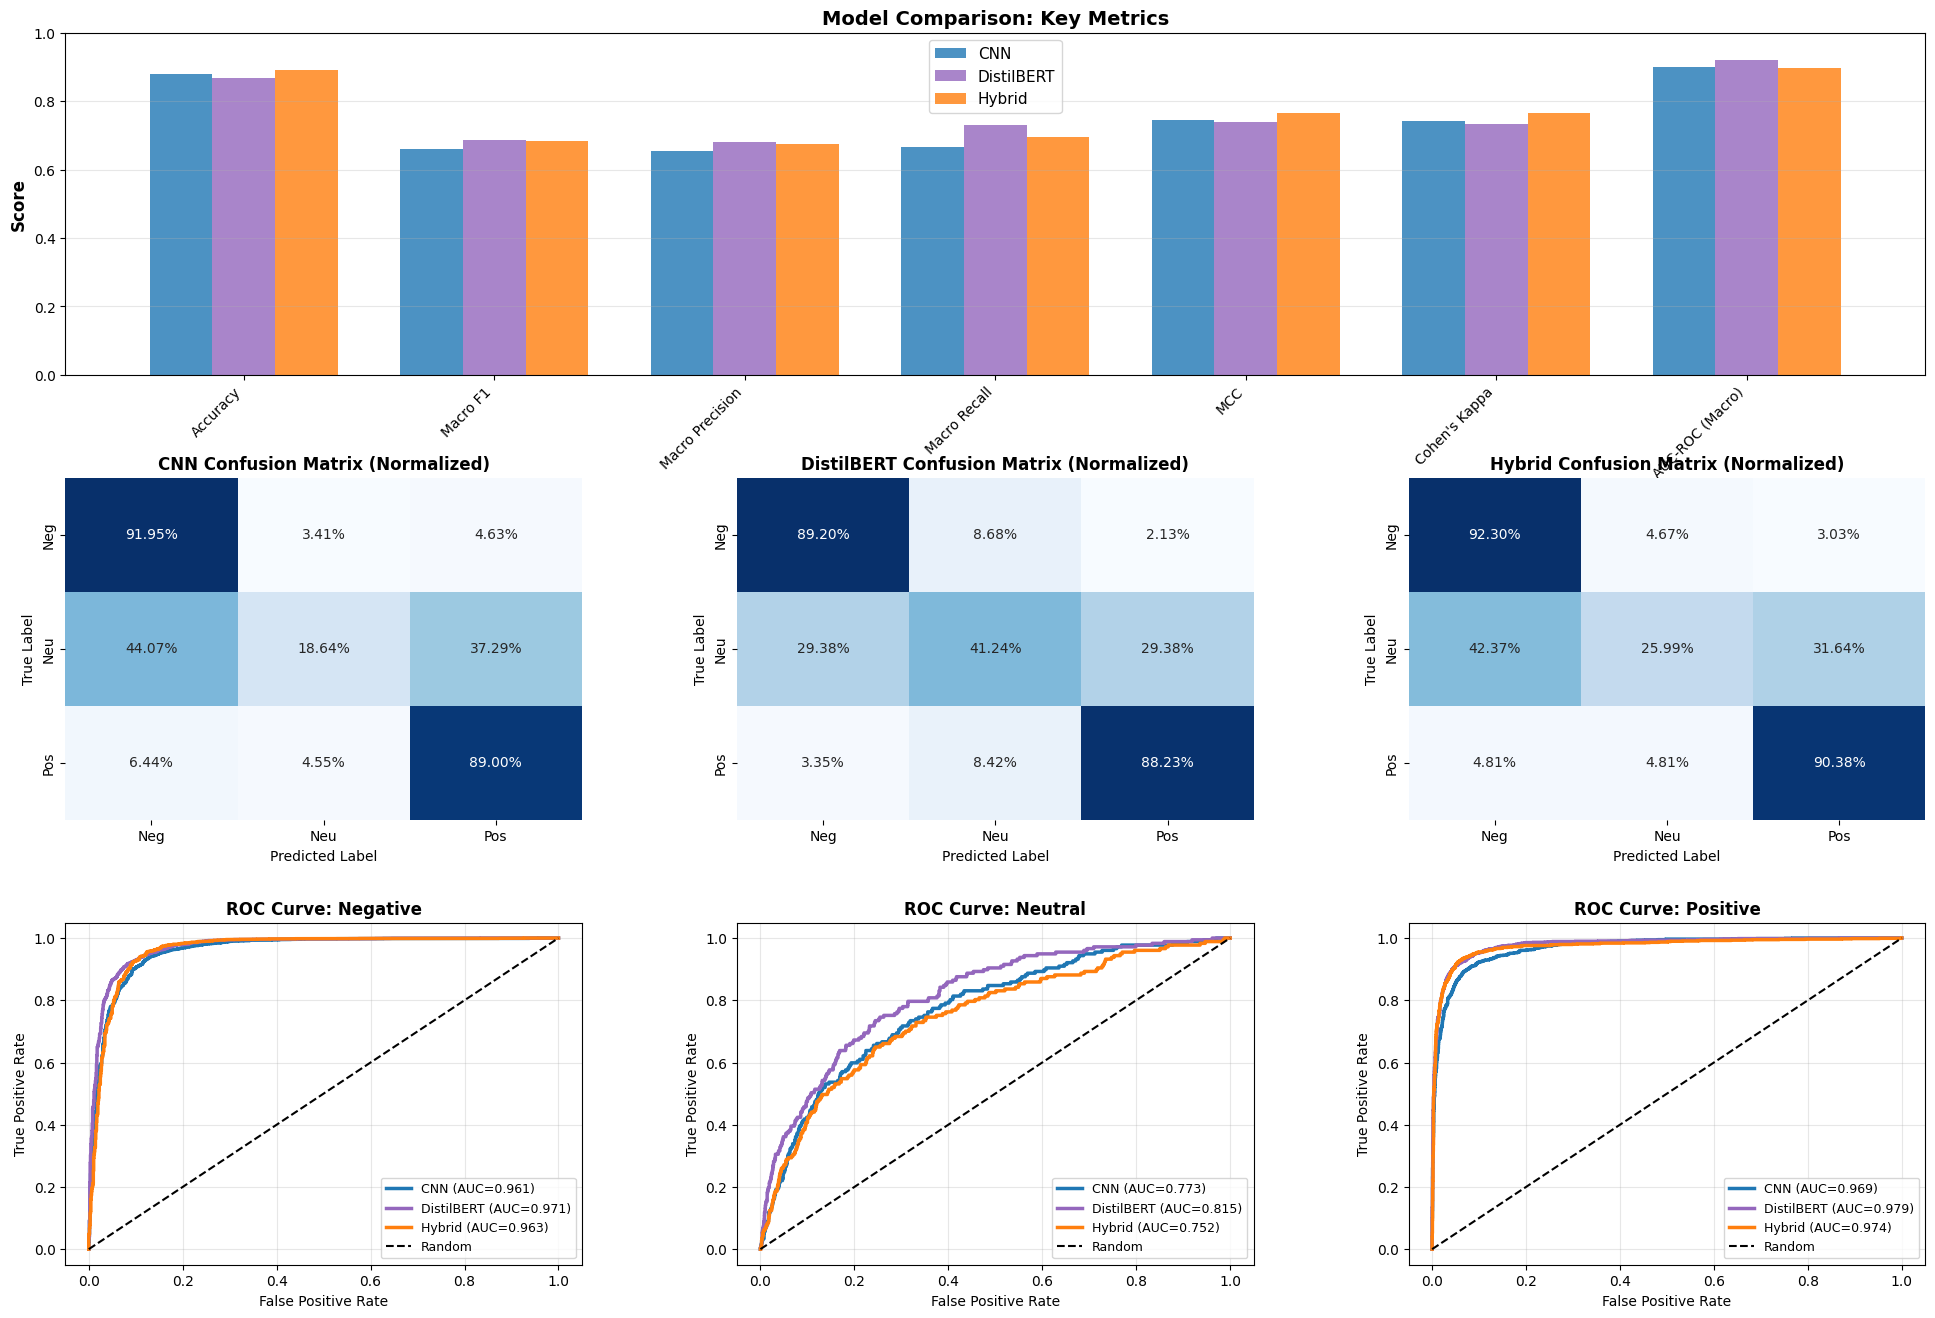

In [40]:
# Colors
color_list = ['#1f77b4', '#9467bd', '#ff7f0e']  # Teal, Purple, Coral

# Create comprehensive comparison figure
fig = plt.figure(figsize=(24, 16))
gs = fig.add_gridspec(3, 3, hspace=0.3, wspace=0.3)

models = ['CNN', 'DistilBERT', 'Hybrid']
metrics_list = [cnn_metrics, bert_metrics, hybrid_metrics]

# ---- Subplot 1: Grouped bar chart ----
ax1 = fig.add_subplot(gs[0, :])
metrics_to_plot = [
    ('accuracy', 'Accuracy'),
    ('f1_macro', 'Macro F1'),
    ('precision_macro', 'Macro Precision'),
    ('recall_macro', 'Macro Recall'),
    ('mcc', 'MCC'),
    ('cohen_kappa', "Cohen's Kappa"),
    ('auc_roc_macro', 'AUC-ROC (Macro)')
]

metric_names = [m[1] for m in metrics_to_plot]
x = np.arange(len(metric_names))
width = 0.25

values_cnn = [cnn_metrics[m[0]] for m in metrics_to_plot]
values_bert = [bert_metrics[m[0]] for m in metrics_to_plot]
values_hybrid = [hybrid_metrics[m[0]] for m in metrics_to_plot]

ax1.bar(x - width, values_cnn, width, label='CNN', color=color_list[0], alpha=0.8)
ax1.bar(x, values_bert, width, label='DistilBERT', color=color_list[1], alpha=0.8)
ax1.bar(x + width, values_hybrid, width, label='Hybrid', color=color_list[2], alpha=0.8)

ax1.set_ylabel('Score', fontsize=12, fontweight='bold')
ax1.set_title('Model Comparison: Key Metrics', fontsize=14, fontweight='bold')
ax1.set_xticks(x)
ax1.set_xticklabels(metric_names, rotation=45, ha='right')
ax1.legend(fontsize=11)
ax1.grid(axis='y', alpha=0.3)
ax1.set_ylim([0, 1])

# ---- Confusion matrices ----
for idx, (model_name, model_metrics_dict) in enumerate(zip(models, metrics_list)):
    ax = fig.add_subplot(gs[1, idx])
    cm = model_metrics_dict['confusion_matrix'].astype('float') / model_metrics_dict['confusion_matrix'].sum(axis=1, keepdims=True)

    sns.heatmap(cm, annot=True, fmt='.2%', cmap='Blues', ax=ax, cbar=False,
                xticklabels=['Neg', 'Neu', 'Pos'],
                yticklabels=['Neg', 'Neu', 'Pos'])
    ax.set_title(f'{model_name} Confusion Matrix (Normalized)', fontsize=12, fontweight='bold')
    ax.set_ylabel('True Label', fontsize=10)
    ax.set_xlabel('Predicted Label', fontsize=10)

# ---- ROC curves per class ----
class_names = ['Negative', 'Neutral', 'Positive']
for class_idx in range(3):
    ax = fig.add_subplot(gs[2, class_idx])

    for model_name, model_metrics_dict, color in zip(models, metrics_list, color_list):
        y_true_binary = (test_labels == class_idx).astype(int)

        if model_name == 'CNN':
            y_pred_probs = cnn_test_pred_probs[:, class_idx]
        elif model_name == 'DistilBERT':
            y_pred_probs = bert_test_pred_probs[:, class_idx]
        else:
            y_pred_probs = hybrid_test_pred_probs[:, class_idx]

        fpr, tpr, _ = roc_curve(y_true_binary, y_pred_probs)
        roc_auc = auc(fpr, tpr)

        ax.plot(fpr, tpr, color=color, lw=2.5, label=f'{model_name} (AUC={roc_auc:.3f})')

    ax.plot([0, 1], [0, 1], 'k--', lw=1.5, label='Random')
    ax.set_xlabel('False Positive Rate', fontsize=10)
    ax.set_ylabel('True Positive Rate', fontsize=10)
    ax.set_title(f'ROC Curve: {class_names[class_idx]}', fontsize=12, fontweight='bold')
    ax.legend(fontsize=9)
    ax.grid(alpha=0.3)

plt.savefig('model_comparison.png', dpi=300, bbox_inches='tight')
print(f"✓ Saved comparison plot: model_comparison.png")
plt.show()

✓ Saved PR and loss plot: pr_and_loss.png


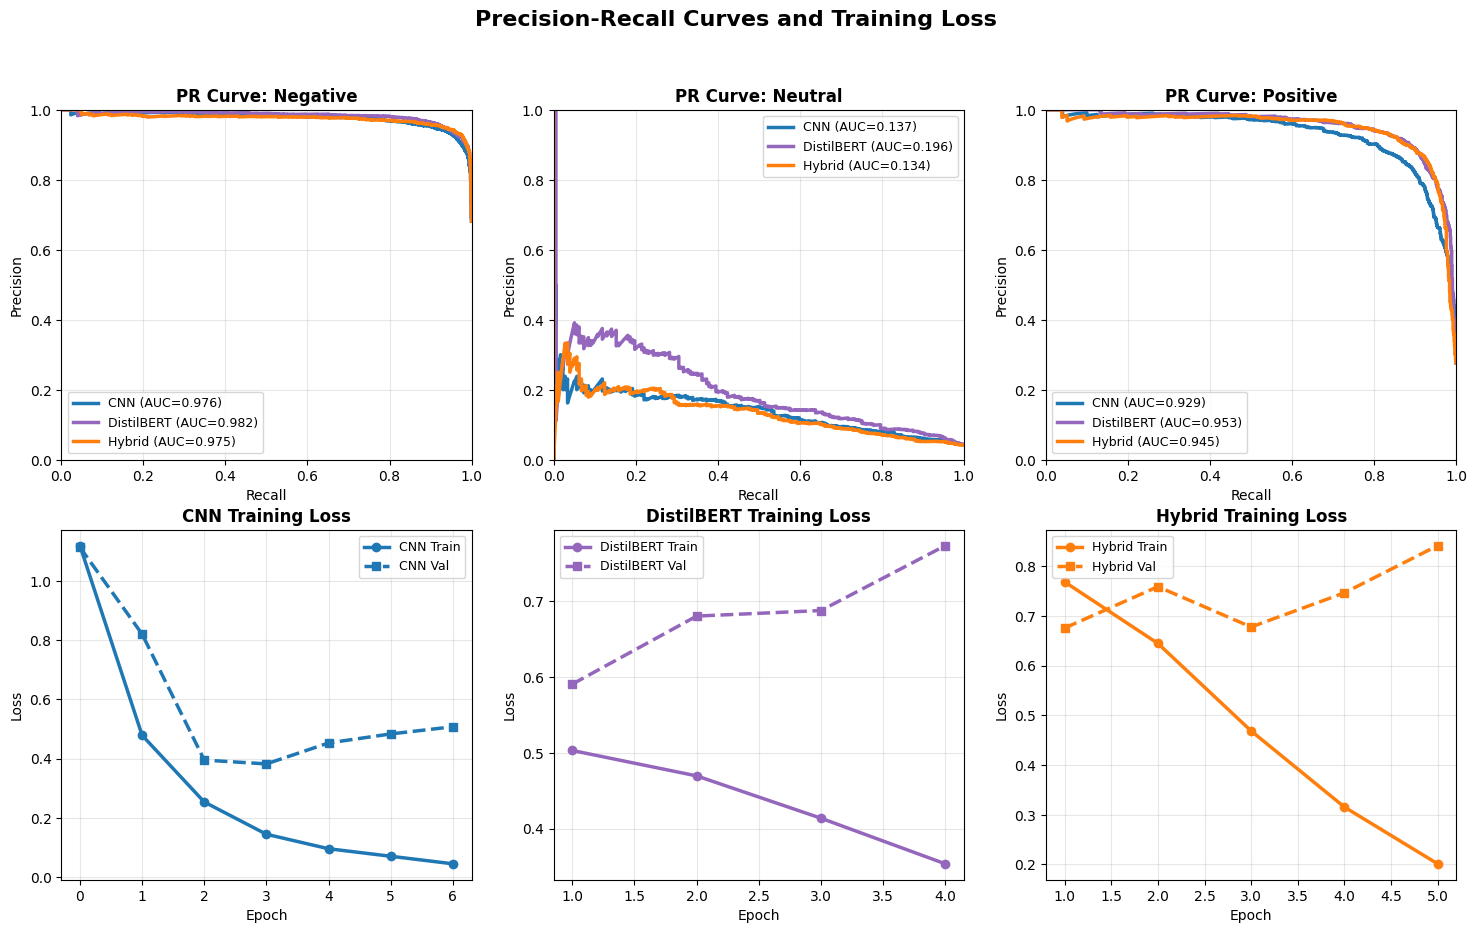

In [41]:
# PR and Training Loss figure
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Precision-Recall Curves and Training Loss', fontsize=16, fontweight='bold')

# PR curves
for class_idx in range(3):
    ax = axes[0, class_idx]

    for model_name, model_metrics_dict, color in zip(models, metrics_list, color_list):
        y_true_binary = (test_labels == class_idx).astype(int)

        if model_name == 'CNN':
            y_pred_probs = cnn_test_pred_probs[:, class_idx]
        elif model_name == 'DistilBERT':
            y_pred_probs = bert_test_pred_probs[:, class_idx]
        else:
            y_pred_probs = hybrid_test_pred_probs[:, class_idx]

        precision_vals, recall_vals, _ = precision_recall_curve(y_true_binary, y_pred_probs)
        pr_auc = auc(recall_vals, precision_vals)

        ax.plot(recall_vals, precision_vals, color=color, lw=2.5, label=f'{model_name} (AUC={pr_auc:.3f})')

    ax.set_xlabel('Recall', fontsize=10)
    ax.set_ylabel('Precision', fontsize=10)
    ax.set_title(f'PR Curve: {class_names[class_idx]}', fontsize=12, fontweight='bold')
    ax.legend(fontsize=9)
    ax.grid(alpha=0.3)
    ax.set_xlim([0, 1])
    ax.set_ylim([0, 1])

# Training loss
ax = axes[1, 0]
ax.plot(cnn_history.history['loss'], color=color_list[0], lw=2.5, label='CNN Train', marker='o')
ax.plot(cnn_history.history['val_loss'], color=color_list[0], lw=2.5, linestyle='--', label='CNN Val', marker='s')
ax.set_xlabel('Epoch', fontsize=10)
ax.set_ylabel('Loss', fontsize=10)
ax.set_title('CNN Training Loss', fontsize=12, fontweight='bold')
ax.legend(fontsize=9)
ax.grid(alpha=0.3)

ax = axes[1, 1]
epochs_bert = np.arange(1, len(bert_train_losses) + 1)
ax.plot(epochs_bert, bert_train_losses, color=color_list[1], lw=2.5, label='DistilBERT Train', marker='o')
ax.plot(epochs_bert, bert_val_losses, color=color_list[1], lw=2.5, linestyle='--', label='DistilBERT Val', marker='s')
ax.set_xlabel('Epoch', fontsize=10)
ax.set_ylabel('Loss', fontsize=10)
ax.set_title('DistilBERT Training Loss', fontsize=12, fontweight='bold')
ax.legend(fontsize=9)
ax.grid(alpha=0.3)

ax = axes[1, 2]
epochs_hybrid = np.arange(1, len(hybrid_train_losses) + 1)
ax.plot(epochs_hybrid, hybrid_train_losses, color=color_list[2], lw=2.5, label='Hybrid Train', marker='o')
ax.plot(epochs_hybrid, hybrid_val_losses, color=color_list[2], lw=2.5, linestyle='--', label='Hybrid Val', marker='s')
ax.set_xlabel('Epoch', fontsize=10)
ax.set_ylabel('Loss', fontsize=10)
ax.set_title('Hybrid Training Loss', fontsize=12, fontweight='bold')
ax.legend(fontsize=9)
ax.grid(alpha=0.3)

plt.savefig('pr_and_loss.png', dpi=300, bbox_inches='tight')
print(f"✓ Saved PR and loss plot: pr_and_loss.png")
plt.show()

✓ Saved timing and params plot: timing_and_params.png


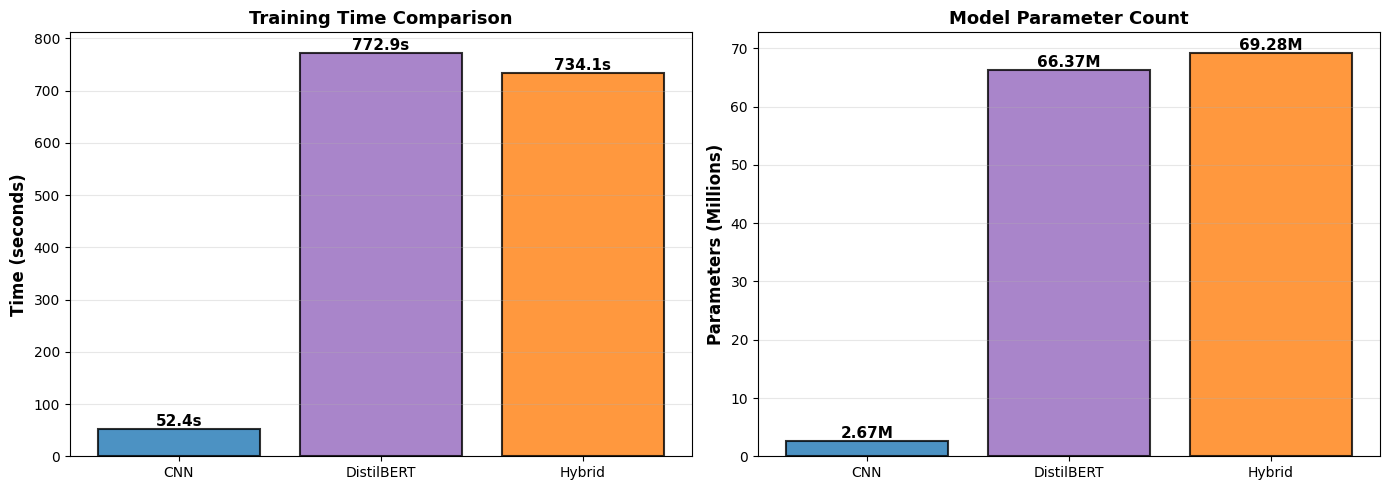

In [42]:
# Training time and parameter count
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Training time
times = [cnn_train_time, bert_train_time, hybrid_train_time]
ax = axes[0]
bars = ax.bar(models, times, color=color_list, alpha=0.8, edgecolor='black', linewidth=1.5)
ax.set_ylabel('Time (seconds)', fontsize=12, fontweight='bold')
ax.set_title('Training Time Comparison', fontsize=13, fontweight='bold')
ax.grid(axis='y', alpha=0.3)
for bar, time in zip(bars, times):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{time:.1f}s', ha='center', va='bottom', fontsize=11, fontweight='bold')

# Parameter count
param_counts = [cnn_param_count / 1e6, bert_param_count / 1e6, hybrid_param_count / 1e6]
ax = axes[1]
bars = ax.bar(models, param_counts, color=color_list, alpha=0.8, edgecolor='black', linewidth=1.5)
ax.set_ylabel('Parameters (Millions)', fontsize=12, fontweight='bold')
ax.set_title('Model Parameter Count', fontsize=13, fontweight='bold')
ax.grid(axis='y', alpha=0.3)
for bar, count in zip(bars, param_counts):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{count:.2f}M', ha='center', va='bottom', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.savefig('timing_and_params.png', dpi=300, bbox_inches='tight')
print(f"✓ Saved timing and params plot: timing_and_params.png")
plt.show()

## Section 8: IEEE-Style Summary Tables

In [43]:
print("\n" + "="*70)
print("SECTION 8: IEEE-STYLE SUMMARY TABLE")
print("="*70 + "\n")

# Main summary table
summary_data = []

for model_name, model_metrics_dict in zip(models, metrics_list):
    row = {
        'Model': model_name,
        'Accuracy': f"{model_metrics_dict['accuracy']:.4f}",
        'Precision (M)': f"{model_metrics_dict['precision_macro']:.4f}",
        'Precision (W)': f"{model_metrics_dict['precision_weighted']:.4f}",
        'Recall (M)': f"{model_metrics_dict['recall_macro']:.4f}",
        'Recall (W)': f"{model_metrics_dict['recall_weighted']:.4f}",
        'F1 (M)': f"{model_metrics_dict['f1_macro']:.4f}",
        'F1 (W)': f"{model_metrics_dict['f1_weighted']:.4f}",
        'MCC': f"{model_metrics_dict['mcc']:.4f}",
        'Kappa': f"{model_metrics_dict['cohen_kappa']:.4f}",
        'AUC-ROC': f"{model_metrics_dict['auc_roc_macro']:.4f}",
        'AUC-PR': f"{model_metrics_dict['auc_pr_macro']:.4f}",
        'Log Loss': f"{model_metrics_dict['log_loss']:.4f}",
    }
    summary_data.append(row)

summary_df = pd.DataFrame(summary_data)

print("TABLE 1: OVERALL PERFORMANCE METRICS")
print("-" * 140)
print(tabulate(summary_df, headers='keys', tablefmt='grid', showindex=False))
print("-" * 140)

# Per-class metrics
print("\n\nTABLE 2: PER-CLASS PRECISION, RECALL, F1-SCORE")
print("-" * 120)

per_class_data = []
class_names_full = ['Negative (1-2 stars)', 'Neutral (3 stars)', 'Positive (4-5 stars)']

for class_idx, class_name in enumerate(class_names_full):
    for model_name, model_metrics_dict in zip(models, metrics_list):
        per_class_data.append({
            'Class': class_name if model_name == models[0] else '',
            'Model': model_name,
            'Precision': f"{model_metrics_dict[f'precision_class_{class_idx}']:.4f}",
            'Recall': f"{model_metrics_dict[f'recall_class_{class_idx}']:.4f}",
            'F1-Score': f"{model_metrics_dict[f'f1_class_{class_idx}']:.4f}",
        })

per_class_df = pd.DataFrame(per_class_data)
print(tabulate(per_class_df, headers='keys', tablefmt='grid', showindex=False))
print("-" * 120)

# Training statistics
print("\n\nTABLE 3: TRAINING STATISTICS")
print("-" * 80)

training_stats = []
for model_name, train_time, param_count in zip(models, [cnn_train_time, bert_train_time, hybrid_train_time],
                                                        [cnn_param_count, bert_param_count, hybrid_param_count]):
    training_stats.append({
        'Model': model_name,
        'Parameters (M)': f"{param_count / 1e6:.2f}",
        'Training Time (s)': f"{train_time:.2f}",
        'Params/Time': f"{param_count / (1e6 * train_time):.4f}",
    })

training_df = pd.DataFrame(training_stats)
print(tabulate(training_df, headers='keys', tablefmt='grid', showindex=False))
print("-" * 80)

# Class-wise AUC scores
print("\n\nTABLE 4: CLASS-WISE AUC SCORES")
print("-" * 100)

auc_data = []
for class_idx, class_name in enumerate(['Negative', 'Neutral', 'Positive']):
    for model_name, model_metrics_dict in zip(models, metrics_list):
        auc_data.append({
            'Class': class_name if model_name == models[0] else '',
            'Model': model_name,
            'AUC-ROC': f"{model_metrics_dict[f'auc_roc_class_{class_idx}']:.4f}",
            'AUC-PR': f"{model_metrics_dict[f'auc_pr_class_{class_idx}']:.4f}",
        })

auc_df = pd.DataFrame(auc_data)
print(tabulate(auc_df, headers='keys', tablefmt='grid', showindex=False))
print("-" * 100)

print("\n" + "="*70)
print("EVALUATION COMPLETE")
print("="*70)
print(f"\nGenerated comparison plots:")
print(f"  - model_comparison.png: Main metrics, confusion matrices, ROC curves")
print(f"  - pr_and_loss.png: PR curves and training loss")
print(f"  - timing_and_params.png: Training time and parameter counts")
print(f"\nAll metrics saved and visualization complete!")


SECTION 8: IEEE-STYLE SUMMARY TABLE

TABLE 1: OVERALL PERFORMANCE METRICS
--------------------------------------------------------------------------------------------------------------------------------------------
+------------+------------+-----------------+-----------------+--------------+--------------+----------+----------+--------+---------+-----------+----------+------------+
| Model      |   Accuracy |   Precision (M) |   Precision (W) |   Recall (M) |   Recall (W) |   F1 (M) |   F1 (W) |    MCC |   Kappa |   AUC-ROC |   AUC-PR |   Log Loss |
+============+============+=================+=================+==============+==============+==========+==========+========+=========+===========+==========+============+
| CNN        |     0.8806 |          0.6545 |          0.8836 |       0.6653 |       0.8806 |   0.6596 |   0.8818 | 0.7438 |  0.7432 |    0.9007 |   0.6806 |     0.3612 |
+------------+------------+-----------------+-----------------+--------------+--------------+-------